# Cluster All Books
Applies the full clustering pipeline to the **AllBooks/** corpus (~98 books, 5 genres).

Pre-computed feature files from `Feature Vector.ipynb` are loaded for BOW, LMF, Stylo+LMF-15, and SBERT.
TF-IDF and Stylometric features are computed inline from the AllBooks text as fallback if files are missing.
A language-detection heuristic (≥60% English tokens) filters non-English books before clustering.

**Run order:** `Feature Vector.ipynb` (AllBooks section) → **`ClusterAllBooks.ipynb`**

**Algorithms:** K-Means · Divisive Hierarchical (Bisecting K-Means) · LDA · GMM · SOM · DEC

**Feature sets:** TF-IDF · TF-IDF-PCA50 · BOW · Stylometric · LMF · Stylo+LMF · Stylo+LMF-15 · SBERT · SBERT-PCA50

**Evaluations:** Silhouette · Cohen's Kappa · Topic Coherence (LDA)

In [59]:
import os, re, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import LatentDirichletAllocation, PCA
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import silhouette_score, cohen_kappa_score
from sklearn.preprocessing import StandardScaler, normalize

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('words',     quiet=True)
from nltk.corpus import stopwords
from nltk.corpus import words as _nltk_words
ENGLISH_VOCAB = set(w.lower() for w in _nltk_words.words())

print(f'All imports successful. English vocabulary: {len(ENGLISH_VOCAB):,} words')

All imports successful. English vocabulary: 234,377 words


## Configuration

In [60]:
ALL_BOOKS_DIR       = 'AllBooks'
IMAGES_DIR          = 'images'
PARTITIONS_PER_BOOK = 200
WORDS_PER_PARTITION = 400
RANDOM_SEED         = 42
N_CLUSTERS          = 5
GENRES              = ['biography', 'fantasy', 'horror', 'romance', 'sci-fi']
os.makedirs(IMAGES_DIR, exist_ok=True)

# Project Gutenberg boilerplate strip patterns
_START = re.compile(r'\*{3}\s*START OF THE PROJECT GUTENBERG EBOOK[^\n]*\*{3}', re.IGNORECASE)
_END   = re.compile(r'\*{3}\s*END OF THE PROJECT GUTENBERG EBOOK[^\n]*\*{3}',   re.IGNORECASE)

def clean_gutenberg(raw):
    m = _START.search(raw)
    text = raw[m.end():] if m else raw
    m = _END.search(text)
    return text[:m.start()].strip() if m else text.strip()

print(f'AllBooks directory : {ALL_BOOKS_DIR}')
print(f'Partitions per book: {PARTITIONS_PER_BOOK} x {WORDS_PER_PARTITION} words')

AllBooks directory : AllBooks
Partitions per book: 200 x 400 words


## Load and Partition All Books
Loads pre-computed partitions from `FeatureTrainingData/allbooks_partitions.csv` if available (generated by `Feature Vector.ipynb`).
Otherwise walks `AllBooks/<genre>/` directories, strips Gutenberg boilerplate, and samples 200 random 400-word partitions per book.

A language-detection filter removes books where fewer than 60% of sampled tokens are found in the NLTK English vocabulary.

In [61]:
def _book_is_english(texts, threshold=0.60, sample_tokens=300):
    """Return True if ≥ threshold of sampled tokens from a book's partitions are English."""
    combined = ' '.join(texts[:5])
    tokens   = re.findall(r'[a-z]+', combined.lower())
    if len(tokens) < 50:
        return True
    sample = tokens[:sample_tokens]
    ratio  = sum(1 for w in sample if w in ENGLISH_VOCAB) / len(sample)
    return ratio >= threshold

rng = random.Random(RANDOM_SEED)
all_records = []

_partitions_path = 'FeatureTrainingData/allbooks_partitions.csv'
if os.path.exists(_partitions_path):
    df = pd.read_csv(_partitions_path)
    print(f'Loaded {len(df):,} pre-computed partitions from {_partitions_path}')

    # Filter out non-English books from the cached data
    _keep, _drop = [], []
    for book, grp in df.groupby('book'):
        if _book_is_english(grp['text'].tolist()):
            _keep.append(book)
        else:
            _drop.append(book)
    if _drop:
        print(f'Removing {len(_drop)} non-English books: {_drop}')
        # Capture original row positions BEFORE reset_index — needed to slice
        # pre-computed feature files (SBERT .npy, BOW/Stylo/LMF CSVs) that were
        # built from the full 19400-row corpus.
        _feat_row_idx = df.index[df['book'].isin(_keep)].values
        df = df[df['book'].isin(_keep)].reset_index(drop=True)
    else:
        print('All cached books appear to be English.')
        _feat_row_idx = np.arange(len(df))
else:
    def _is_english_raw(text, threshold=0.60, sample_tokens=300):
        tokens = re.findall(r'[a-z]+', text.lower()[:10000])
        if len(tokens) < 50:
            return True
        sample = tokens[:sample_tokens]
        return sum(1 for w in sample if w in ENGLISH_VOCAB) / len(sample) >= threshold

    skipped = []
    for genre in GENRES:
        genre_dir = Path(ALL_BOOKS_DIR) / genre
        if not genre_dir.exists():
            print(f'  [WARN] {genre_dir} not found — skipping')
            continue
        txt_files = sorted(genre_dir.glob('*.txt'))
        print(f'{genre} ({len(txt_files)} books):')
        for fpath in txt_files:
            try:
                raw = fpath.read_text(encoding='utf-8', errors='ignore')
            except Exception:
                raw = fpath.read_text(encoding='latin-1', errors='ignore')
            text = clean_gutenberg(raw)
            if not _is_english_raw(text):
                print(f'    [SKIP] {fpath.name} — non-English')
                skipped.append(fpath.name)
                continue
            tokens = text.split()
            if len(tokens) < WORDS_PER_PARTITION + 50:
                print(f'    [SKIP] {fpath.name} — too short ({len(tokens)} words)')
                continue
            max_start = len(tokens) - WORDS_PER_PARTITION
            n = min(PARTITIONS_PER_BOOK, max_start)
            starts = rng.sample(range(max_start + 1), n)
            for i, s in enumerate(starts):
                all_records.append({
                    'partition_id': f'{fpath.stem}_part_{i:03d}',
                    'book':   fpath.stem,
                    'genre':  genre,
                    'text':   ' '.join(tokens[s: s + WORDS_PER_PARTITION]),
                })
            print(f'    {fpath.name}: {len(tokens):,} words -> {n} partitions')
    if skipped:
        print(f'\nSkipped {len(skipped)} non-English books: {skipped}')
    df = pd.DataFrame(all_records)
    _feat_row_idx = np.arange(len(df))  # built from scratch — all rows aligned
    os.makedirs('FeatureTrainingData', exist_ok=True)
    df.to_csv(_partitions_path, index=False)
    print(f'Saved partitions → {_partitions_path}')

print(f'\nTotal partitions: {len(df):,}')
print(df['genre'].value_counts().to_string())

Loaded 19,400 pre-computed partitions from FeatureTrainingData/allbooks_partitions.csv
Removing 2 non-English books: [14214, 16120]

Total partitions: 19,000
genre
fantasy      4000
romance      4000
sci-fi       3800
biography    3600
horror       3600


## Feature Extraction
Loads pre-computed feature files from `Feature Vector.ipynb` where available, or computes inline as fallback.

| Feature | File | Notes |
|---------|------|-------|
| **TF-IDF** (5000-feat) | Computed inline | Fitted fresh on AllBooks corpus |
| **BOW** (1026-feat) | `allbooks_bow_features.csv` | Uses curated KnownBooks vocabulary |
| **Stylometric** (10-feat) | `allbooks_stylometric_features.csv` | Loaded or computed inline |
| **LMF** (9-feat) | `allbooks_lmf_features.csv` | POS-based ratios; ~30 min to compute |
| **Stylo+LMF-15** | `selected_stylo_lmf_features.json` | Top-15 features by MI + redundancy filter |
| **SBERT** (384-d) | `allbooks_sbert_features.npy` | `all-MiniLM-L6-v2` semantic embeddings |

In [62]:
X_text   = df['text'].tolist()
y_true   = df['genre'].tolist()
part_ids = df['partition_id'].tolist()

# Native TF-IDF (5000 features, fitted on AllBooks corpus)
tfidf_vec = TfidfVectorizer(max_features=5000, stop_words='english',
                             ngram_range=(1, 2), sublinear_tf=True)
X_tfidf   = tfidf_vec.fit_transform(X_text)
print(f'TF-IDF (native 5000-feat): {X_tfidf.shape}')

# Raw counts for LDA
count_vec = CountVectorizer(max_features=5000, stop_words='english', min_df=2)
X_count   = count_vec.fit_transform(X_text)
lda_vocab = count_vec.get_feature_names_out()
print(f'CountVec (LDA): {X_count.shape}')

# Curated-vocabulary BOW (from Feature Vector.ipynb)
# Use _feat_row_idx to align with the language-filtered df (may be < 19400 rows)
_bow_path = 'FeatureTrainingData/allbooks_bow_features.csv'
if os.path.exists(_bow_path):
    _bow_df = pd.read_csv(_bow_path)
    _meta   = ['partition_id', 'book', 'genre']
    X_bow   = (_bow_df.iloc[_feat_row_idx]
                       .drop(columns=[c for c in _meta if c in _bow_df.columns])
                       .values.astype(np.float32))
    print(f'BOW (curated vocab, loaded): {X_bow.shape}')
else:
    X_bow = None
    print('BOW not available — run Feature Vector.ipynb AllBooks section first')

TF-IDF (native 5000-feat): (19000, 5000)
CountVec (LDA): (19000, 5000)
BOW (curated vocab, loaded): (19000, 1026)


In [63]:
import re as _re
from collections import Counter as _Ctr

def _sylls(word):
    w, vowels, c, p = word.lower(), 'aeiouy', 0, False
    for ch in w:
        v = ch in vowels
        if v and not p: c += 1
        p = v
    return max(1, c)

def stylometric_features(text):
    words = _re.findall(r'[a-zA-Z]+', text)
    sents = [s.strip() for s in _re.split(r'[.!?]+', text) if s.strip()]
    if not words:
        return dict.fromkeys(['avg_word_len','avg_sent_len','sent_len_std',
                               'type_token_ratio','punct_density','comma_ratio',
                               'semicolon_ratio','quote_density','avg_syllables',
                               'hapax_ratio'], 0.0)
    wl   = [len(w) for w in words]
    sl   = [len(_re.findall(r'[a-zA-Z]+', s)) for s in sents]
    sl   = [x for x in sl if x > 0] or [len(words)]
    uniq = set(w.lower() for w in words)
    freq = _Ctr(w.lower() for w in words)
    hapax = sum(1 for f in freq.values() if f == 1)
    return {
        'avg_word_len':     float(np.mean(wl)),
        'avg_sent_len':     float(np.mean(sl)),
        'sent_len_std':     float(np.std(sl)),
        'type_token_ratio': len(uniq) / len(words),
        'punct_density':    len(_re.findall(r'[.,!?;:()"-]', text)) / max(len(words), 1),
        'comma_ratio':      text.count(',') / max(len(words), 1),
        'semicolon_ratio':  text.count(';') / max(len(words), 1),
        'quote_density':    (text.count('"') + text.count("'")) / max(len(words), 1),
        'avg_syllables':    float(np.mean([_sylls(w) for w in words])),
        'hapax_ratio':      hapax / max(len(uniq), 1),
    }

_stylo_path = 'FeatureTrainingData/allbooks_stylometric_features.csv'
if os.path.exists(_stylo_path):
    _stylo_raw = (pd.read_csv(_stylo_path)
                    .iloc[_feat_row_idx]
                    .drop(columns=['partition_id', 'book', 'genre'], errors='ignore')
                    .values)
    X_stylo = StandardScaler().fit_transform(_stylo_raw.astype(np.float32))
    print(f'Stylometric (loaded): {X_stylo.shape}')
else:
    print('Computing stylometric features...')
    stylo_rows = [stylometric_features(t) for t in X_text]
    X_stylo = StandardScaler().fit_transform(pd.DataFrame(stylo_rows).values)
    print(f'Stylometric (computed): {X_stylo.shape}')

Stylometric (loaded): (19000, 10)


In [64]:
import json as _json

# Load SBERT — slice with _feat_row_idx to align with the filtered df
_sbert_npy = 'FeatureTrainingData/allbooks_sbert_features.npy'
if os.path.exists(_sbert_npy):
    X_sbert = np.load(_sbert_npy)[_feat_row_idx].astype(np.float32)
    print(f'SBERT (loaded): {X_sbert.shape}')
else:
    try:
        from sentence_transformers import SentenceTransformer
        print('Loading SBERT model (all-MiniLM-L6-v2)...')
        sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
        print(f'Encoding {len(X_text):,} partitions...')
        X_sbert = sbert_model.encode(X_text, batch_size=128,
                                      show_progress_bar=True, convert_to_numpy=True)
        print(f'SBERT: {X_sbert.shape}')
    except ImportError:
        print('sentence-transformers not installed — SBERT skipped.')
        X_sbert = None

# Load LMF — slice with _feat_row_idx
_lmf_path = 'FeatureTrainingData/allbooks_lmf_features.csv'
if os.path.exists(_lmf_path):
    _lmf_raw = (pd.read_csv(_lmf_path)
                  .iloc[_feat_row_idx]
                  .drop(columns=['partition_id', 'book', 'genre'], errors='ignore')
                  .values)
    X_lmf = StandardScaler().fit_transform(_lmf_raw.astype(np.float32))
    print(f'LMF (loaded): {X_lmf.shape}')
else:
    X_lmf = None
    print('LMF not available — run Feature Vector.ipynb AllBooks section first')

# PCA-reduced versions for GMM / SOM / DEC
X_tfidf_dense = X_tfidf.toarray().astype(np.float32)
X_tfidf_pca   = PCA(n_components=50, random_state=42).fit_transform(X_tfidf_dense)
if X_sbert is not None:
    X_sbert_pca = PCA(n_components=50, random_state=42).fit_transform(X_sbert)
else:
    X_sbert_pca = X_tfidf_pca

# Shared feature set used by every algorithm
ALL_FEATURES = {
    'TF-IDF':       X_tfidf_dense,
    'TF-IDF-PCA50': X_tfidf_pca,
    'Stylometric':  X_stylo,
}
if X_bow is not None:
    ALL_FEATURES['BOW'] = X_bow
if X_lmf is not None:
    ALL_FEATURES['LMF'] = X_lmf
if X_bow is not None and X_lmf is not None:
    ALL_FEATURES['Stylo+LMF'] = np.hstack([X_stylo, X_lmf])
if X_sbert is not None:
    ALL_FEATURES['SBERT']       = X_sbert
    ALL_FEATURES['SBERT-PCA50'] = X_sbert_pca

# Stylo+LMF-15 — slice CSVs with _feat_row_idx before selecting top-15 columns
_sel_path = 'FeatureTrainingData/selected_stylo_lmf_features.json'
if os.path.exists(_sel_path) and X_lmf is not None:
    with open(_sel_path) as _f:
        _sel_feats = _json.load(_f)
    _meta   = {'partition_id', 'book', 'genre'}
    _s_path = 'FeatureTrainingData/allbooks_stylometric_features.csv'
    _l_path = 'FeatureTrainingData/allbooks_lmf_features.csv'
    if os.path.exists(_s_path) and os.path.exists(_l_path):
        _s_df   = pd.read_csv(_s_path).iloc[_feat_row_idx]
        _l_df   = pd.read_csv(_l_path).iloc[_feat_row_idx]
        _s_cols = [c for c in _s_df.columns if c not in _meta]
        _l_cols = [c for c in _l_df.columns if c not in _meta]
        _all_f  = _s_cols + _l_cols
        _X_raw  = np.hstack([_s_df[_s_cols].values, _l_df[_l_cols].values])
        _idx15  = [_all_f.index(f) for f in _sel_feats if f in _all_f]
        X_stylo_lmf_sel = StandardScaler().fit_transform(_X_raw[:, _idx15].astype(np.float32))
        ALL_FEATURES['Stylo+LMF-15'] = X_stylo_lmf_sel
        print(f'Stylo+LMF-15 (selected): {X_stylo_lmf_sel.shape}')
    else:
        X_stylo_lmf_sel = np.hstack([X_stylo, X_lmf]) if X_lmf is not None else X_stylo
        print('allbooks stylo/LMF CSVs not found — Stylo+LMF-15 skipped')
else:
    X_stylo_lmf_sel = np.hstack([X_stylo, X_lmf]) if X_lmf is not None else X_stylo
    if not os.path.exists(_sel_path):
        print('selected_stylo_lmf_features.json not found — run Feature Vector.ipynb first')

print('Feature sets ready:', list(ALL_FEATURES.keys()))

SBERT (loaded): (19000, 384)
LMF (loaded): (19000, 9)
Stylo+LMF-15 (selected): (19000, 15)
Feature sets ready: ['TF-IDF', 'TF-IDF-PCA50', 'Stylometric', 'BOW', 'LMF', 'Stylo+LMF', 'SBERT', 'SBERT-PCA50', 'Stylo+LMF-15']


## Helpers

In [65]:
def map_clusters(y_true, y_pred):
    arr = np.array(y_true)
    mapping = {cid: Counter(arr[y_pred == cid]).most_common(1)[0][0]
               for cid in np.unique(y_pred) if (y_pred == cid).sum() > 0}
    return np.array([mapping.get(p, 'unknown') for p in y_pred]), mapping

def evaluate(X, y_true, y_pred):
    X_e = X if X.shape[1] <= 50 else PCA(n_components=50, random_state=42).fit_transform(X)
    try:
        sil = float(silhouette_score(X_e, y_pred,
                                     sample_size=min(3000, len(y_pred)),
                                     random_state=42))
    except Exception:
        sil = float('nan')
    mapped, _ = map_clusters(y_true, y_pred)
    kap = float(cohen_kappa_score(y_true, mapped))
    return sil, kap

all_results = []
all_preds   = []
print('Helpers defined.')

Helpers defined.


In [66]:
# Top-5 feature sets for non-LDA algorithms (ranked by silhouette in Feature Vector.ipynb)
import json as _json
_rank_path = 'FeatureTrainingData/top_features_ranked.json'
if os.path.exists(_rank_path):
    with open(_rank_path) as _f:
        _ranked_names = _json.load(_f)
    _top5_names = [f for f in _ranked_names if f in ALL_FEATURES][:5]
    print(f'Top 5 features (Feature Vector.ipynb silhouette ranking): {_top5_names}')
else:
    _top5_names = [k for k in ['SBERT-PCA50', 'SBERT', 'TF-IDF-PCA50', 'Stylo+LMF', 'Stylometric'] if k in ALL_FEATURES]
    print(f'Ranking file not found ? using fallback: {_top5_names}')

TOP5_FEATURES = {k: ALL_FEATURES[k] for k in _top5_names}
print('TOP5_FEATURES:', list(TOP5_FEATURES.keys()))


Top 3 features (Feature Vector.ipynb silhouette ranking): ['SBERT', 'Stylometric', 'Stylo+LMF']
TOP3_FEATURES: ['SBERT', 'Stylometric', 'Stylo+LMF']


## 1. K-Means

In [67]:
print(f'K-Means (top-3 features: {list(TOP5_FEATURES.keys())}):')
for feat_name, X in TOP5_FEATURES.items():
    km     = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
    y_pred = km.fit_predict(X)
    sil, kap = evaluate(X, y_true, y_pred)
    mapped, _ = map_clusters(y_true, y_pred)
    all_results.append({'Algorithm': 'K-Means', 'Feature': feat_name,
                        'Silhouette': round(sil,4), 'Kappa': round(kap,4), 'Coherence': None})
    all_preds.append((y_pred, mapped))
    print(f'  {feat_name:14} -> Silhouette={sil:.4f}  Kappa={kap:.4f}')

K-Means (top-3 features: ['SBERT', 'Stylometric', 'Stylo+LMF']):
  SBERT          -> Silhouette=0.0617  Kappa=0.2547
  Stylometric    -> Silhouette=0.1397  Kappa=0.1000
  Stylo+LMF      -> Silhouette=0.1182  Kappa=0.1194


## 2. Divisive Hierarchical (Bisecting K-Means)

In [68]:
def bisecting_kmeans(X, n_clusters=5, random_state=42):
    rng    = np.random.RandomState(random_state)
    labels = np.zeros(len(X), dtype=int)
    n_cur  = 1
    while n_cur < n_clusters:
        sizes  = np.bincount(labels, minlength=n_cur)
        target = int(np.argmax(sizes))
        mask   = labels == target
        if mask.sum() < 2: break
        km2    = KMeans(n_clusters=2, random_state=int(rng.randint(0, 9999)), n_init=5)
        sub    = km2.fit_predict(X[mask])
        labels[mask] = np.where(sub == 0, target, n_cur)
        n_cur += 1
    return labels

print(f'Divisive Hierarchical (top-3 features: {list(TOP5_FEATURES.keys())}):')
for feat_name, X in TOP5_FEATURES.items():
    y_pred = bisecting_kmeans(X, n_clusters=N_CLUSTERS)
    sil, kap = evaluate(X, y_true, y_pred)
    mapped, _ = map_clusters(y_true, y_pred)
    all_results.append({'Algorithm': 'Divisive Hierarchical', 'Feature': feat_name,
                        'Silhouette': round(sil,4), 'Kappa': round(kap,4), 'Coherence': None})
    all_preds.append((y_pred, mapped))
    print(f'  {feat_name:14} -> Silhouette={sil:.4f}  Kappa={kap:.4f}')

Divisive Hierarchical (top-3 features: ['SBERT', 'Stylometric', 'Stylo+LMF']):
  SBERT          -> Silhouette=0.0329  Kappa=0.2831
  Stylometric    -> Silhouette=0.1399  Kappa=0.1133
  Stylo+LMF      -> Silhouette=0.1059  Kappa=0.1003


## 3. LDA as Clustering

In [69]:
lda = LatentDirichletAllocation(n_components=N_CLUSTERS, random_state=42,
                                 learning_method='batch', max_iter=50, n_jobs=-1)
X_lda_probs = lda.fit_transform(X_count)
y_pred_lda  = np.argmax(X_lda_probs, axis=1)
sil_lda, kap_lda = evaluate(X_lda_probs, y_true, y_pred_lda)
mapped_lda, _    = map_clusters(y_true, y_pred_lda)

coherence_score = None
try:
    from gensim.models.coherencemodel import CoherenceModel
    from gensim.corpora import Dictionary as GDict
    tok_texts = [[w.lower() for w in t.split() if w.isalpha() and len(w) > 2] for t in X_text]
    gdict = GDict(tok_texts)
    topics_top = []
    for i in range(N_CLUSTERS):
        top_ids = lda.components_[i].argsort()[-10:][::-1]
        topics_top.append([lda_vocab[j] for j in top_ids])
    cm_obj = CoherenceModel(topics=topics_top, texts=tok_texts, dictionary=gdict, coherence='c_v')
    coherence_score = round(cm_obj.get_coherence(), 4)
    print(f'LDA coherence (C_V): {coherence_score}')
except ImportError:
    print('gensim not installed — coherence skipped')

all_results.append({'Algorithm': 'LDA', 'Feature': 'CountVec',
                    'Silhouette': round(sil_lda,4), 'Kappa': round(kap_lda,4),
                    'Coherence': coherence_score})
all_preds.append((y_pred_lda, mapped_lda))
print(f'  CountVec       -> Silhouette={sil_lda:.4f}  Kappa={kap_lda:.4f}  Coherence={coherence_score}')

print('\nLDA Topic -> Top 10 Words:')
for i in range(N_CLUSTERS):
    top_ids = lda.components_[i].argsort()[-10:][::-1]
    top_w   = [lda_vocab[j] for j in top_ids]
    dom     = Counter(np.array(y_true)[y_pred_lda == i]).most_common(1)[0][0] \
              if (y_pred_lda == i).sum() > 0 else '?'
    top_str = ', '.join(top_w)
    print(f'  Topic {i} ({dom:10}): {top_str}')

LDA coherence (C_V): 0.4348
  CountVec       -> Silhouette=0.5474  Kappa=0.2878  Coherence=0.4348

LDA Topic -> Top 10 Words:
  Topic 0 (fantasy   ): shall, states, et, le, la, united, state, je, plus, president
  Topic 1 (sci-fi    ): like, came, saw, did, great, little, eyes, said, time, long
  Topic 2 (biography ): time, men, great, new, people, work, life, general, years, man
  Topic 3 (biography ): did, man, said, lord, thou, god, shall, love, good, king
  Topic 4 (romance   ): said, mr, little, know, think, good, don, did, time, mrs


## 4. Gaussian Mixture Model (GMM)
Soft probabilistic clustering with per-cluster Gaussian distributions.
Features with dim > 100 are skipped to avoid covariance estimation failure — use `-PCA50` variants instead.

In [70]:
print(f'GMM (top-3 features: {list(TOP5_FEATURES.keys())}):')
for feat_name, X in TOP5_FEATURES.items():
    if X.shape[1] > 100:
        print(f'  {feat_name:14} -> skipped (dim={X.shape[1]}, use {feat_name}-PCA50 instead)')
        continue
    X64 = X.astype(np.float64)
    cov = 'full' if X.shape[1] <= 50 else 'diag'
    try:
        gmm    = GaussianMixture(n_components=N_CLUSTERS, random_state=42,
                                 covariance_type=cov, n_init=3, reg_covar=1e-3)
        y_pred = gmm.fit_predict(X64)
    except Exception:
        gmm    = GaussianMixture(n_components=N_CLUSTERS, random_state=42,
                                 covariance_type='diag', n_init=3, reg_covar=1e-3)
        y_pred = gmm.fit_predict(X64)
    sil, kap = evaluate(X64, y_true, y_pred)
    mapped, _ = map_clusters(y_true, y_pred)
    all_results.append({'Algorithm': 'GMM', 'Feature': feat_name,
                        'Silhouette': round(sil,4), 'Kappa': round(kap,4), 'Coherence': None})
    all_preds.append((y_pred, mapped))
    print(f'  {feat_name:14} -> Silhouette={sil:.4f}  Kappa={kap:.4f}  [{cov}]')

GMM (top-3 features: ['SBERT', 'Stylometric', 'Stylo+LMF']):
  SBERT          -> skipped (dim=384, use SBERT-PCA50 instead)
  Stylometric    -> Silhouette=0.0769  Kappa=0.1392  [full]
  Stylo+LMF      -> Silhouette=0.0629  Kappa=0.1203  [full]


## 5. Self-Organizing Maps (SOM)
Requires `minisom`: `pip install minisom`

In [71]:
try:
    from minisom import MiniSom

    def run_som(X, n_clusters=5, grid=10, iters=3000, seed=42):
        X_n = normalize(X.astype(np.float32))
        som = MiniSom(grid, grid, X_n.shape[1], sigma=1.5, learning_rate=0.5,
                      neighborhood_function='gaussian', random_seed=seed)
        som.random_weights_init(X_n)
        som.train_random(X_n, iters, verbose=False)
        bmu_w = np.array([som.get_weights()[som.winner(x)] for x in X_n])
        return KMeans(n_clusters=n_clusters, random_state=seed, n_init=10).fit_predict(bmu_w)

    print(f'SOM (top-3 features: {list(TOP5_FEATURES.keys())}):')
    for feat_name, X in TOP5_FEATURES.items():
        y_pred = run_som(X, n_clusters=N_CLUSTERS)
        sil, kap = evaluate(X, y_true, y_pred)
        mapped, _ = map_clusters(y_true, y_pred)
        all_results.append({'Algorithm': 'SOM', 'Feature': feat_name,
                            'Silhouette': round(sil,4), 'Kappa': round(kap,4), 'Coherence': None})
        all_preds.append((y_pred, mapped))
        print(f'  {feat_name:14} -> Silhouette={sil:.4f}  Kappa={kap:.4f}')

except ImportError:
    print('minisom not installed — skipping SOM.  Run: pip install minisom')

SOM (top-3 features: ['SBERT', 'Stylometric', 'Stylo+LMF']):
  SBERT          -> Silhouette=0.0276  Kappa=0.1486
  Stylometric    -> Silhouette=0.0862  Kappa=0.1238
  Stylo+LMF      -> Silhouette=0.0656  Kappa=0.0703


## 6. Deep Embedded Clustering (DEC)
Requires TensorFlow: `pip install tensorflow`

In [72]:
try:
    import tensorflow as tf
    from tensorflow import keras
    tf.get_logger().setLevel('ERROR')

    def build_autoencoder(in_dim, latent=32):
        inp = keras.Input(shape=(in_dim,))
        h   = keras.layers.Dense(256, activation='relu')(inp)
        h   = keras.layers.Dropout(0.2)(h)
        h   = keras.layers.Dense(128, activation='relu')(h)
        z   = keras.layers.Dense(latent, activation='relu', name='z')(h)
        d   = keras.layers.Dense(128, activation='relu')(z)
        d   = keras.layers.Dense(256, activation='relu')(d)
        out = keras.layers.Dense(in_dim, activation='linear')(d)
        return keras.Model(inp, out), keras.Model(inp, z)

    def run_dec(X, n_clusters=5, latent=32, epochs=30, seed=42):
        tf.random.set_seed(seed); np.random.seed(seed)
        X32 = X.astype(np.float32)
        lo, hi = X32.min(0), X32.max(0)
        rng = hi - lo; rng[rng == 0] = 1
        Xn  = (X32 - lo) / rng
        ae, enc = build_autoencoder(Xn.shape[1], latent)
        ae.compile(optimizer='adam', loss='mse')
        ae.fit(Xn, Xn, epochs=epochs, batch_size=256, verbose=0)
        Z  = enc.predict(Xn, verbose=0)
        return KMeans(n_clusters=n_clusters, random_state=seed, n_init=10).fit_predict(Z), Z

    print(f'DEC (top-3 features: {list(TOP5_FEATURES.keys())}):')
    for feat_name, X in TOP5_FEATURES.items():
        y_pred, Z = run_dec(X, n_clusters=N_CLUSTERS)
        sil, kap  = evaluate(Z, y_true, y_pred)
        mapped, _ = map_clusters(y_true, y_pred)
        all_results.append({'Algorithm': 'DEC', 'Feature': feat_name,
                            'Silhouette': round(sil,4), 'Kappa': round(kap,4), 'Coherence': None})
        all_preds.append((y_pred, mapped))
        print(f'  {feat_name:14} -> Silhouette={sil:.4f}  Kappa={kap:.4f}')

except ImportError:
    print('TensorFlow not installed — skipping DEC.  Run: pip install tensorflow')

DEC (top-3 features: ['SBERT', 'Stylometric', 'Stylo+LMF']):
  SBERT          -> Silhouette=0.1572  Kappa=0.2297
  Stylometric    -> Silhouette=0.1711  Kappa=0.1020
  Stylo+LMF      -> Silhouette=0.1342  Kappa=0.0939


## Evaluation Results
Silhouette, Kappa, and Coherence across all algorithm / feature combinations.

In [73]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(['Algorithm', 'Kappa'], ascending=[True, False])

print('=' * 70)
print('EVALUATION TABLE — ALL BOOKS CORPUS')
print('=' * 70)
print(results_df.to_string(index=False))

best_idx = results_df['Kappa'].idxmax()
best_row = results_df.loc[best_idx]
print(f'\nBest (by Kappa): {best_row["Algorithm"]} + {best_row["Feature"]}')
print(f'  Silhouette={best_row["Silhouette"]:.4f}  Kappa={best_row["Kappa"]:.4f}')

EVALUATION TABLE — ALL BOOKS CORPUS
            Algorithm     Feature  Silhouette  Kappa  Coherence
                  DEC       SBERT      0.1572 0.2297        NaN
                  DEC Stylometric      0.1711 0.1020        NaN
                  DEC   Stylo+LMF      0.1342 0.0939        NaN
Divisive Hierarchical       SBERT      0.0329 0.2831        NaN
Divisive Hierarchical Stylometric      0.1399 0.1133        NaN
Divisive Hierarchical   Stylo+LMF      0.1059 0.1003        NaN
                  GMM Stylometric      0.0769 0.1392        NaN
                  GMM   Stylo+LMF      0.0629 0.1203        NaN
              K-Means       SBERT      0.0617 0.2547        NaN
              K-Means   Stylo+LMF      0.1182 0.1194        NaN
              K-Means Stylometric      0.1397 0.1000        NaN
                  LDA    CountVec      0.5474 0.2878     0.4348
                  SOM       SBERT      0.0276 0.1486        NaN
                  SOM Stylometric      0.0862 0.1238        NaN
    

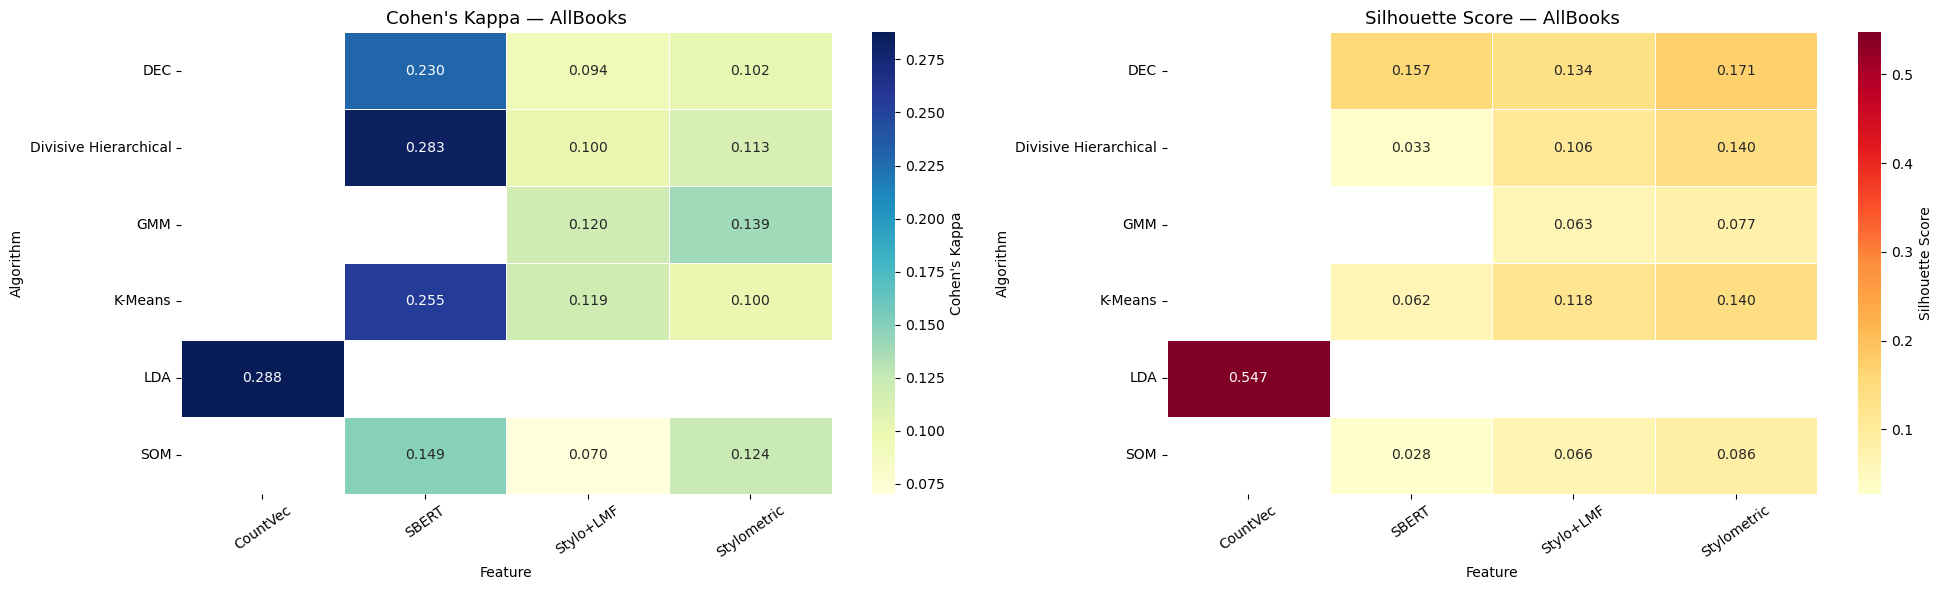

Saved: images/allbooks_evaluation_heatmap.png


In [74]:
pivot_k = results_df.pivot_table(index='Algorithm', columns='Feature', values='Kappa',      aggfunc='max')
pivot_s = results_df.pivot_table(index='Algorithm', columns='Feature', values='Silhouette', aggfunc='max')

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
sns.heatmap(pivot_k, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[0],
            cbar_kws={'label': "Cohen's Kappa"}, linewidths=0.5)
axes[0].set_title("Cohen's Kappa — AllBooks", fontsize=13)
axes[0].tick_params(axis='x', rotation=35)

sns.heatmap(pivot_s, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1],
            cbar_kws={'label': 'Silhouette Score'}, linewidths=0.5)
axes[1].set_title('Silhouette Score — AllBooks', fontsize=13)
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig('images/allbooks_evaluation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/allbooks_evaluation_heatmap.png')

## Error Analysis
Confusion matrix and most-confused partitions for the best-performing model.

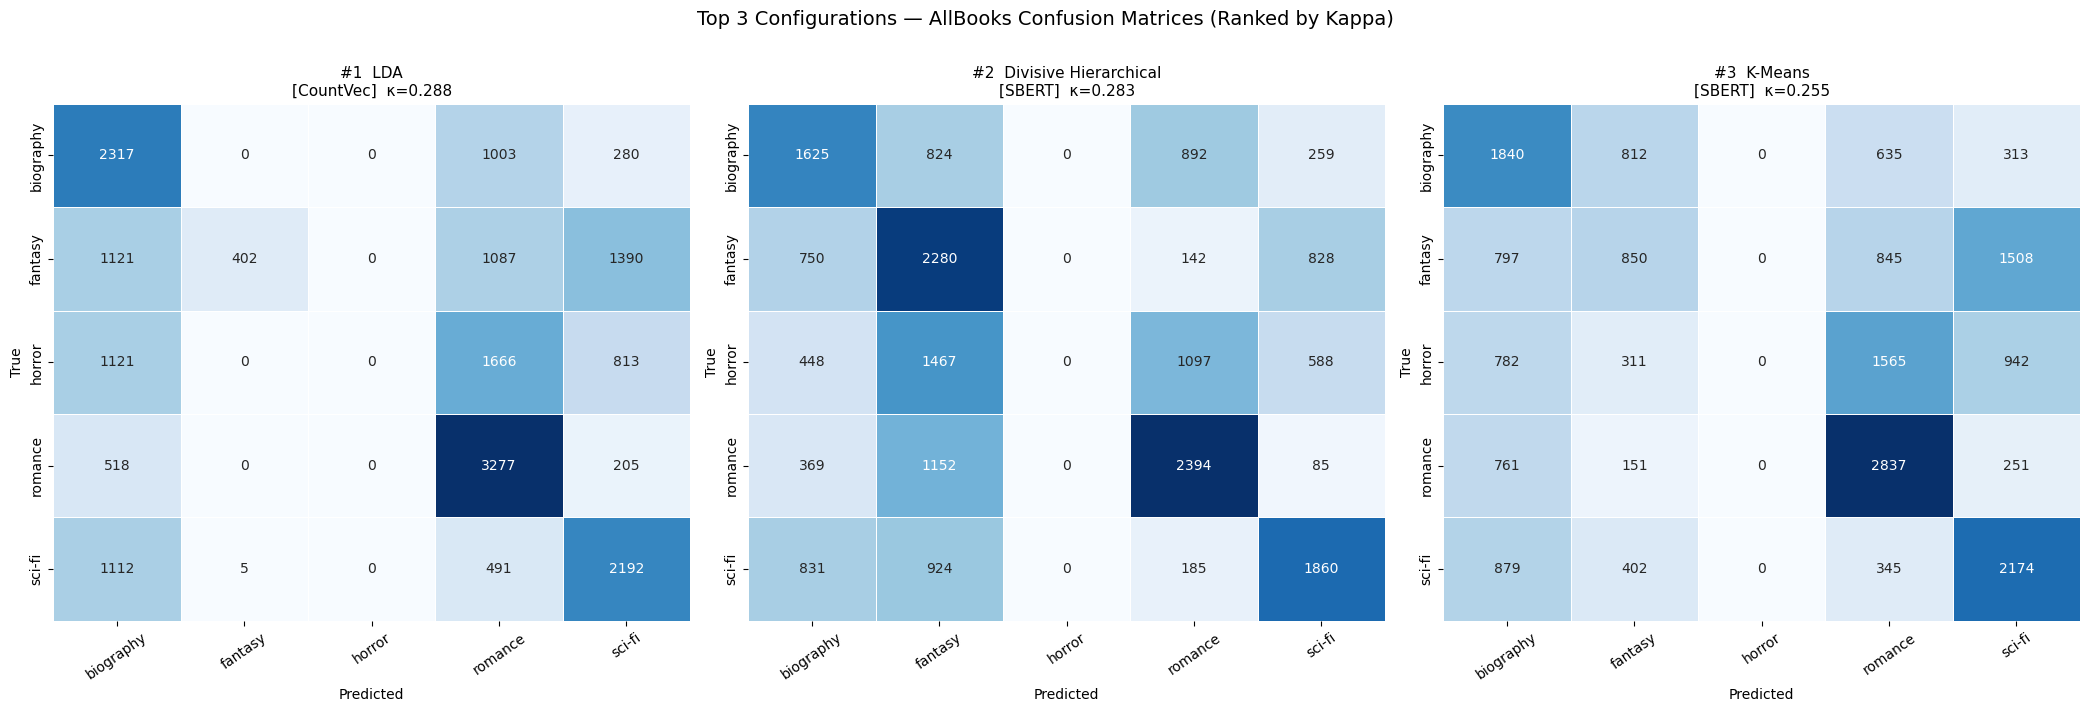

Saved: images/allbooks_top3_confusion.png

Champion: LDA + CountVec


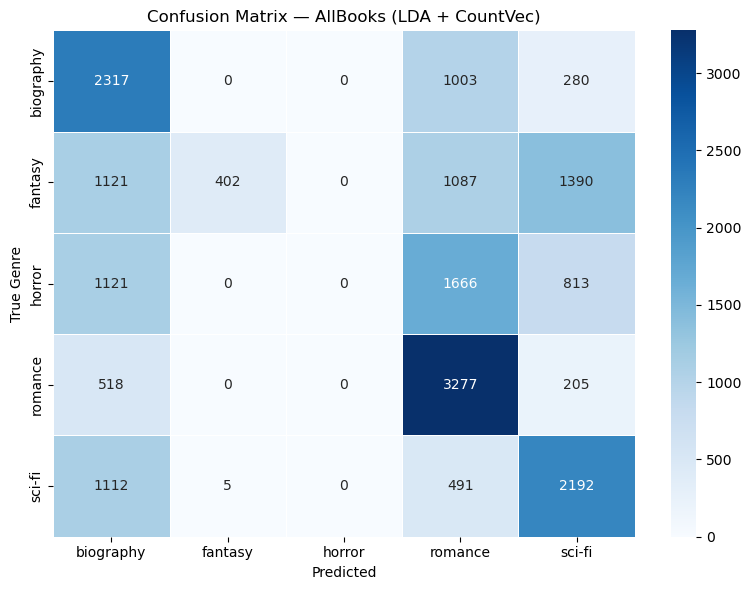

Saved: images/allbooks_confusion_matrix.png

Total misclassified: 10812/19000 (56.9%)

Per-genre error rate:
  biography   : 1283/3600 (35.6%)
  fantasy     : 3598/4000 (90.0%)
  horror      : 3600/3600 (100.0%)
  romance     : 723/4000 (18.1%)
  sci-fi      : 1608/3800 (42.3%)

Top 10 confusion pairs:


,true,pred,count
6,horror,romance,1666
4,fantasy,sci-fi,1390
2,fantasy,biography,1121
5,horror,biography,1121
10,sci-fi,biography,1112
3,fantasy,romance,1087
0,biography,romance,1003
7,horror,sci-fi,813
8,romance,biography,518
12,sci-fi,romance,491


In [75]:
from sklearn.metrics import confusion_matrix

orig_df = pd.DataFrame(all_results)
top5    = results_df.nlargest(5, 'Kappa').reset_index(drop=True)

# ?? Top-5 confusion matrices (2 ? 3 grid) ????????????????????????????????????
fig, axes = plt.subplots(2, 3, figsize=(21, 14))
axes = axes.flatten()
for ax_idx, row in top5.iterrows():
    algo = row['Algorithm']
    feat = row['Feature']
    match    = orig_df.index[(orig_df['Algorithm'] == algo) &
                              (orig_df['Feature']   == feat)].tolist()
    pred_idx  = match[0] if match else 0
    _, mapped = all_preds[pred_idx]
    cm = confusion_matrix(y_true, mapped, labels=GENRES)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=GENRES, yticklabels=GENRES,
                ax=axes[ax_idx], linewidths=0.4, cbar=False)
    axes[ax_idx].set_title(f'#{ax_idx+1}  {algo}\n[{feat}]  ?={row["Kappa"]:.3f}', fontsize=11)
    axes[ax_idx].set_xlabel('Predicted')
    axes[ax_idx].set_ylabel('True')
    axes[ax_idx].tick_params(axis='x', rotation=35)
axes[5].set_visible(False)
plt.suptitle('Top 5 Configurations ? AllBooks Confusion Matrices (Ranked by Kappa)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('images/allbooks_top5_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/allbooks_top5_confusion.png')

# ?? Champion confusion matrix (full-size) ????????????????????????????
best_algo = results_df.loc[results_df['Kappa'].idxmax(), 'Algorithm']
best_feat = results_df.loc[results_df['Kappa'].idxmax(), 'Feature']
match     = orig_df.index[(orig_df['Algorithm'] == best_algo) &
                           (orig_df['Feature']   == best_feat)].tolist()
champ_pos = match[0] if match else 0
y_pred_best, mapped_best = all_preds[champ_pos]

print(f'\nChampion: {best_algo} + {best_feat}')
cm = confusion_matrix(y_true, mapped_best, labels=GENRES)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GENRES, yticklabels=GENRES, ax=ax, linewidths=0.5)
ax.set_title(f'Confusion Matrix ? AllBooks ({best_algo} + {best_feat})')
ax.set_xlabel('Predicted')
ax.set_ylabel('True Genre')
plt.tight_layout()
plt.savefig('images/allbooks_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/allbooks_confusion_matrix.png')

# ?? Error statistics ????????????????????????????????????????????????????????????
err_df = pd.DataFrame({'partition_id': part_ids, 'text': X_text,
                        'true': y_true, 'pred': list(mapped_best)})
errors = err_df[err_df['true'] != err_df['pred']]
print(f'\nTotal misclassified: {len(errors)}/{len(df)} ({len(errors)/len(df):.1%})')
print('\nPer-genre error rate:')
for g in GENRES:
    tot = (err_df['true'] == g).sum()
    err = ((err_df['true'] == g) & (err_df['true'] != err_df['pred'])).sum()
    print(f'  {g:12}: {err}/{tot} ({err/max(tot,1):.1%})')
print('\nTop 10 confusion pairs:')
pairs = (errors.groupby(['true', 'pred'])
               .size().reset_index(name='count')
               .sort_values('count', ascending=False))
display(pairs.head(10))


In [76]:
print('Sample misclassified partitions (2 per genre):')
for g in GENRES:
    subset = errors[errors['true'] == g].head(2)
    if subset.empty: continue
    print(f'\n  [{g.upper()}]')
    for _, row in subset.iterrows():
        print(f'    Predicted : {row["pred"]}')
        print(f'    ID        : {row["partition_id"]}')
        print(f'    Snippet   : {row["text"][:200]}...')

Sample misclassified partitions (2 per genre):

  [BIOGRAPHY]
    Predicted : romance
    ID        : 11030_part_000
    Snippet   : readiness, but the vessel was unexpectedly detained several days. Meantime, news came to town of a most horrible murder committed on a fugitive slave, named James. Charity, the mother of this unfortun...
    Predicted : romance
    ID        : 11030_part_001
    Snippet   : “The mayor of Boston won’t trouble himself to hunt niggers for Dr. Flint. The letters will do good in the end. I shall get out of this dark hole some time or other.” “I hope you will, child,” replied ...

  [FANTASY]
    Predicted : romance
    ID        : 10662_part_000
    Snippet   : her pain. And lo! she put out her arms to me, and came into mine arms with a little run. And there she bode, weeping strangely; but yet with rest upon her; even as rest was come sudden and wondrous up...
    Predicted : sci-fi
    ID        : 10662_part_001
    Snippet   : I go thus, and came at last to

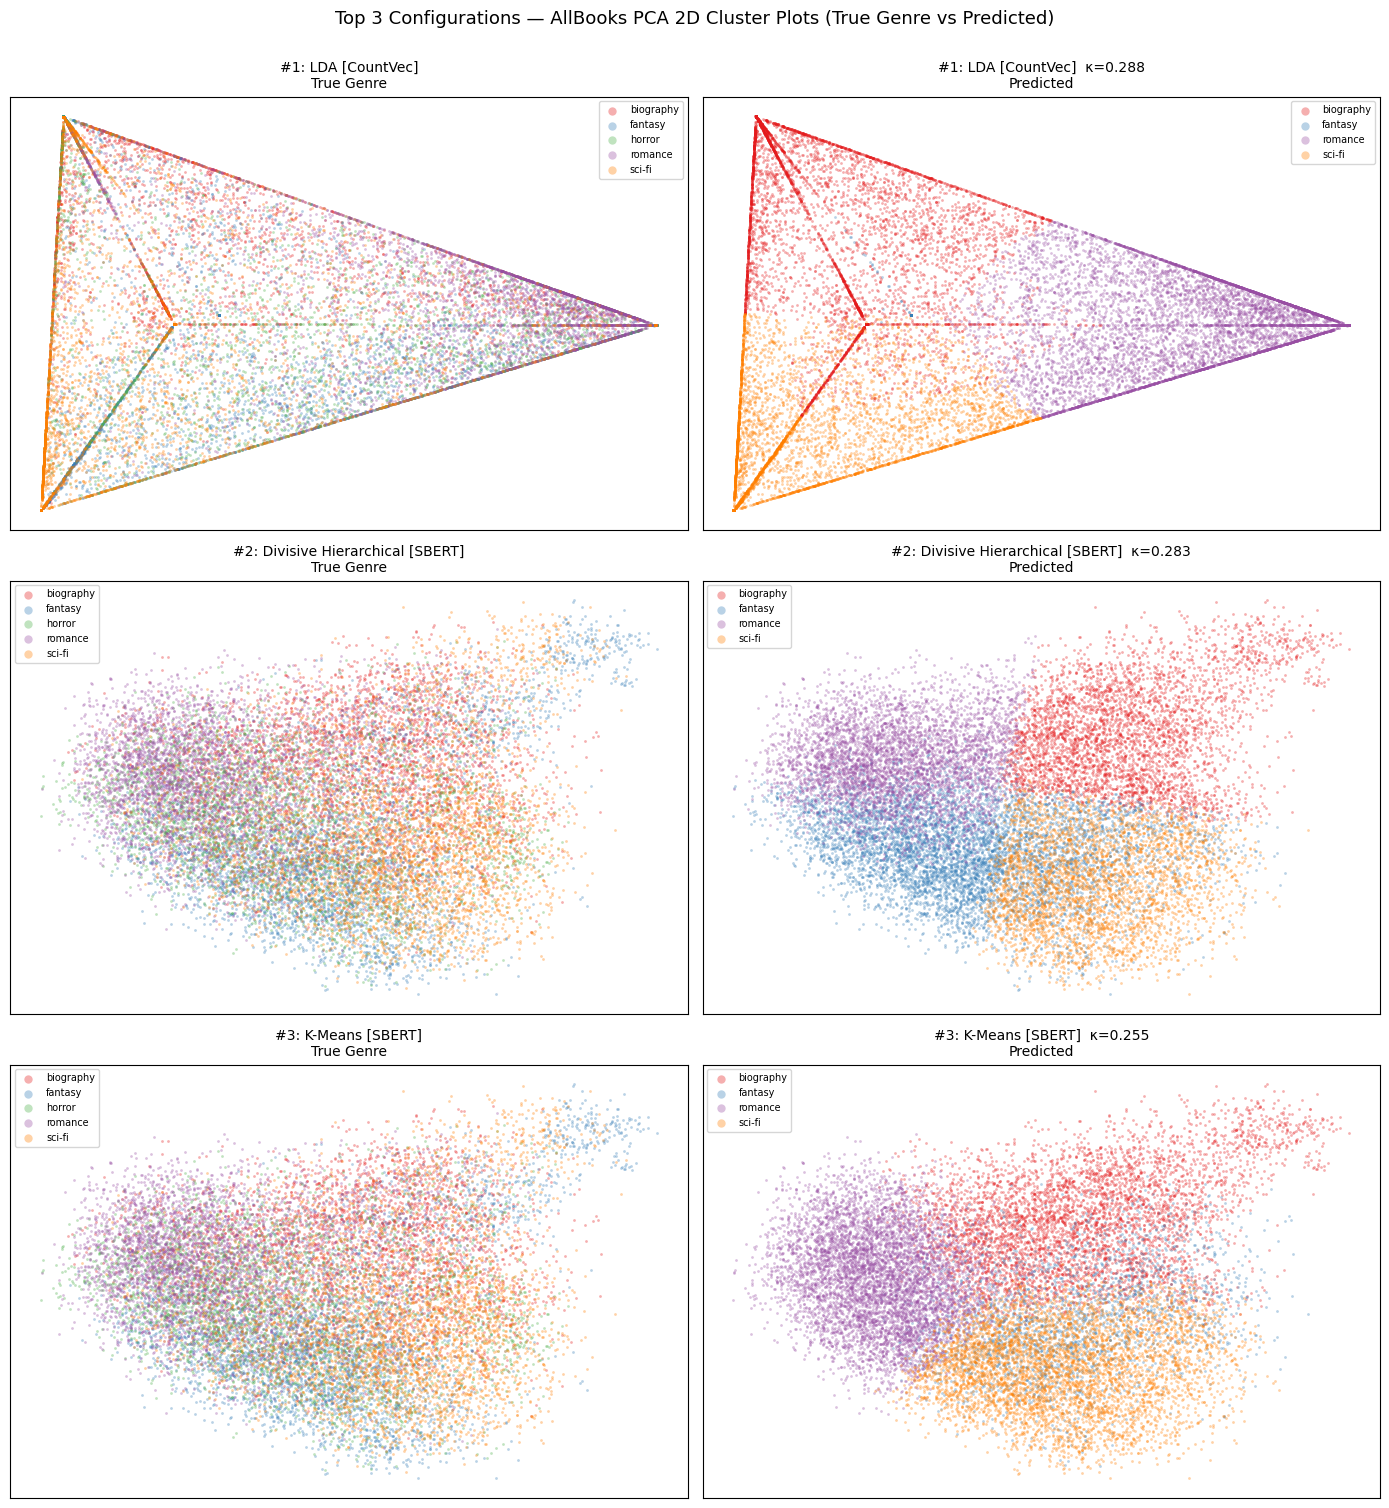

Saved: images/allbooks_top3_cluster_plots.png


In [77]:
GENRE_PALETTE = {
    'biography': '#e41a1c',
    'fantasy':   '#377eb8',
    'horror':    '#4daf4a',
    'romance':   '#984ea3',
    'sci-fi':    '#ff7f00',
    'unknown':   '#aaaaaa',
}

_feat_map = {
    'TF-IDF':        X_tfidf_dense,
    'TF-IDF-PCA50':  X_tfidf_pca,
    'Stylometric':   X_stylo,
    'CountVec':      X_lda_probs,
    'BOW':           X_bow           if X_bow   is not None else X_tfidf_pca,
    'LMF':           X_lmf           if X_lmf   is not None else X_stylo,
    'Stylo+LMF':     (np.hstack([X_stylo, X_lmf]) if X_lmf is not None else X_stylo),
    'Stylo+LMF-15':  X_stylo_lmf_sel,
    'SBERT':         X_sbert         if X_sbert is not None else X_tfidf_pca,
    'SBERT-PCA50':   X_sbert_pca,
}

orig_df    = pd.DataFrame(all_results)
top5       = results_df.nlargest(5, 'Kappa').reset_index(drop=True)
y_true_arr = np.array(y_true)

fig, axes = plt.subplots(5, 2, figsize=(14, 25))

for row_idx, (_, row) in enumerate(top5.iterrows()):
    algo  = row['Algorithm']
    feat  = row['Feature']
    kappa = row['Kappa']

    match    = orig_df.index[(orig_df['Algorithm'] == algo) &
                              (orig_df['Feature']   == feat)].tolist()
    pred_idx  = match[0] if match else 0
    _, mapped = all_preds[pred_idx]
    mapped    = np.array(mapped)

    X_feat = _feat_map.get(feat, X_tfidf_pca)
    X2d    = (PCA(n_components=2, random_state=42).fit_transform(X_feat)
              if X_feat.shape[1] > 2 else X_feat)

    ax_true = axes[row_idx, 0]
    ax_pred = axes[row_idx, 1]

    for genre, colour in GENRE_PALETTE.items():
        mask = y_true_arr == genre
        if not mask.any(): continue
        ax_true.scatter(X2d[mask, 0], X2d[mask, 1],
                        c=colour, label=genre, s=4, alpha=0.35, linewidths=0)
    ax_true.set_title(f'#{row_idx+1}: {algo} [{feat}]\nTrue Genre', fontsize=10)
    ax_true.legend(markerscale=3, fontsize=7, loc='best')
    ax_true.set_xticks([]); ax_true.set_yticks([])

    for label in sorted(set(mapped)):
        colour = GENRE_PALETTE.get(label, '#aaaaaa')
        mask = mapped == label
        ax_pred.scatter(X2d[mask, 0], X2d[mask, 1],
                        c=colour, label=label, s=4, alpha=0.35, linewidths=0)
    ax_pred.set_title(f'#{row_idx+1}: {algo} [{feat}]  ?={kappa:.3f}\nPredicted', fontsize=10)
    ax_pred.legend(markerscale=3, fontsize=7, loc='best')
    ax_pred.set_xticks([]); ax_pred.set_yticks([])

plt.suptitle('Top 5 Configurations ? AllBooks PCA 2D Cluster Plots (True Genre vs Predicted)',
             fontsize=13, y=1.002)
plt.tight_layout()
plt.savefig('images/allbooks_top5_cluster_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/allbooks_top5_cluster_plots.png')


## Top 20 Frequent Words and Collocations per Cluster

In [78]:
mapped_arr = np.array(mapped_best)
print('Top 20 words / collocations per cluster\n')
for genre_name in GENRES:
    mask = mapped_arr == genre_name
    if not mask.any():
        print(f'[{genre_name}] — no samples\n')
        continue
    texts_c = [X_text[i] for i in range(len(X_text)) if mask[i]]
    cv_t    = CountVectorizer(stop_words='english', ngram_range=(1, 2),
                              max_features=20000, min_df=1)
    X_t     = cv_t.fit_transform(texts_c)
    vocab_t = cv_t.get_feature_names_out()
    freq_t  = np.asarray(X_t.sum(axis=0)).flatten()
    top20   = freq_t.argsort()[::-1][:20]
    true_cnts = Counter(np.array(y_true)[mask])
    purity    = true_cnts.most_common(1)[0][1] / mask.sum()
    dominant  = true_cnts.most_common(1)[0][0]
    print(f'Cluster -> "{genre_name.upper()}"  ({mask.sum()} partitions, '
          f'purity={purity:.1%}, dominant true genre="{dominant}")')
    term_df = pd.DataFrame([(vocab_t[i], int(freq_t[i])) for i in top20],
                           columns=['term', 'count'])
    term_df.index += 1
    display(term_df)
    print()

Top 20 words / collocations per cluster

Cluster -> "BIOGRAPHY"  (6189 partitions, purity=37.4%, dominant true genre="biography")


,term,count
1,said,4909
2,man,4812
3,did,4427
4,time,4239
5,great,3338
6,men,3135
7,life,3051
8,good,3016
9,shall,2976
10,like,2880



Cluster -> "FANTASY"  (407 partitions, purity=98.8%, dominant true genre="fantasy")


,term,count
1,shall,3639
2,et,1480
3,states,1393
4,le,1294
5,la,1034
6,united,958
7,united states,955
8,je,923
9,plus,905
10,que,844



[horror] — no samples

Cluster -> "ROMANCE"  (7524 partitions, purity=43.6%, dominant true genre="romance")


,term,count
1,said,17020
2,mr,8171
3,little,7371
4,know,6454
5,did,6087
6,time,5789
7,man,5737
8,like,5505
9,good,5379
10,think,5033



Cluster -> "SCI-FI"  (4880 partitions, purity=44.9%, dominant true genre="sci-fi")


,term,count
1,said,4805
2,did,4129
3,like,4055
4,came,3409
5,little,3341
6,man,3235
7,time,3196
8,great,3180
9,saw,2938
10,eyes,2606
